# Softmax Regression from Scratch

The aim of this notebook is to implement **softmax regression** from scratch using only NumPy. Softmax regression, also known as **multinomial logistic regression**, is a generalization of logistic regression that can handle multiple classes.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Generate synthetic dataset
X, y = load_iris(return_X_y=True)

In [3]:
X.shape, y.shape

((150, 4), (150,))

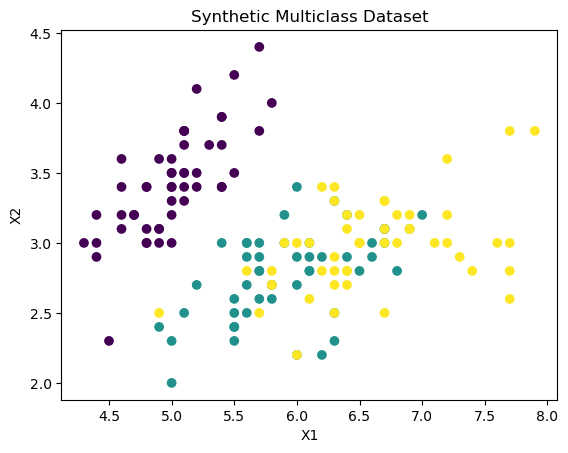

In [4]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Multiclass Dataset")
plt.show()

In [5]:
# One hot encode the labels
num_classes = len(np.unique(y)) # number of unique classes, here it is 3 for the iris dataset
y_one_hot = np.zeros((y.shape[0], num_classes))
for i in range(y.shape[0]):
    y_one_hot[i, y[i]] = 1

In [6]:
# Initialize weights and bias
num_features = X.shape[1] # input features, here it is 4 for the iris dataset
w = np.random.rand(num_features, num_classes) * 0.01 # size (4, 3), the 0.01 is used to keep small weights at the beginning
b = np.zeros((1, num_classes)) # size (1, 3)

In [7]:
# Softmax function from scratch
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) # subtract max for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [9]:
# Estimate y_hat using the softmax function (forward pass)
y_hat = softmax(np.dot(X, w) + b)

In [12]:
# y_hat

In [ ]:
# Check that the probabilities sum to 1 for each sample (e.g. for the first 5 samples)
y_hat.sum(axis=1)[:5]

array([1., 1., 1., 1., 1.])

In [11]:
print("Shape of y_hat:", y_hat.shape)
print("Shape of X:", X.shape)
print("Shape of w:", w.shape)
print("Shape of y_one_hot", y_one_hot.shape)

Shape of y_hat: (150, 3)
Shape of X: (150, 4)
Shape of w: (4, 3)
Shape of y_one_hot (150, 3)


In [15]:
# Categorical cross-entropy loss function (CCE)
def categorical_cross_entropy(y_true, y_pred):
    m = y_true.shape[0] # number of samples
    # Clip y_pred to prevent log(0) which is undefined
    y_pred_clipped = np.clip(y_pred, 1e-15, None)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / m
    return loss

Gradients: 

$$
\frac{\partial W}{\partial L} = n \, X^{\top} (\hat{Y} - Y)
$$

$$
\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$


In [21]:
# Loss after one update
initial_loss = categorical_cross_entropy(y_one_hot, y_hat)
print("Initial loss:", initial_loss)

Initial loss: 1.0964568036169233


In [16]:
# Gradients (for backward pass)
dL_dw = (1 / y_one_hot.shape[0]) * np.dot(X.T, (y_hat - y_one_hot))
dL_db = (1 / y_one_hot.shape[0]) * np.sum(y_hat - y_one_hot, axis=0, keepdims=True)

In [17]:
print("Gradient w.r.t weights (dL_dw) shape:", dL_dw.shape)
print("Gradient w.r.t biases (dL_db) shape:", dL_db.shape)

Gradient w.r.t weights (dL_dw) shape: (4, 3)
Gradient w.r.t biases (dL_db) shape: (1, 3)


In [18]:
# Update step (Gradient descent)
learning_rate = 0.1
w -= learning_rate * dL_dw
b -= learning_rate * dL_db

In [19]:
print("w after update:", w)
print("b after update:", b)

w after update: [[-0.01889927  0.00449579  0.02891497]
 [ 0.01828275 -0.00333045  0.00374087]
 [-0.06683507  0.01892051  0.06435223]
 [-0.02909148  0.0106487   0.03499403]]
b after update: [[ 0.00117025 -0.00101142 -0.00015883]]


In [20]:
# Loss computation after one update step
y_hat_updated = softmax(np.dot(X, w) + b)
loss = categorical_cross_entropy(y_one_hot, y_hat_updated)
print("Loss after one update step:", loss)

Loss after one update step: 1.0312829146404392


The loss has decreased, gradient descent is heading in the right direction.

In [22]:
# Training loop
learning_rate = 0.1
num_iterations = 1000
loss_history = []

# Initialize weights and bias
num_features = X.shape[1] # input features, here it is 4 for the iris dataset
w = np.random.rand(num_features, num_classes) * 0.01 # size (4, 3), the 0.01 is used to keep small weights at the beginning
b = np.zeros((1, num_classes)) # size (1, 3)

for i in range(num_iterations):
    # Forward pass
    y_hat = softmax(np.dot(X, w) + b)
    
    # Compute loss
    loss = categorical_cross_entropy(y_one_hot, y_hat)
    loss_history.append(loss)
    
    # Backward pass (compute gradients)
    dL_dw = (1 / y_one_hot.shape[0]) * np.dot(X.T, (y_hat - y_one_hot))
    dL_db = (1 / y_one_hot.shape[0]) * np.sum(y_hat - y_one_hot, axis=0, keepdims=True)
    
    # Update weights and bias
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db
    
    # Print loss every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss}")

Iteration 0, Loss: 1.095402159063197
Iteration 100, Loss: 0.4418635616206354
Iteration 200, Loss: 0.26199781401144845
Iteration 300, Loss: 0.21880730650631477
Iteration 400, Loss: 0.19143560536816928
Iteration 500, Loss: 0.17239642820466575
Iteration 600, Loss: 0.15833515415226038
Iteration 700, Loss: 0.14749024360011947
Iteration 800, Loss: 0.13884725572576576
Iteration 900, Loss: 0.1317803867155627


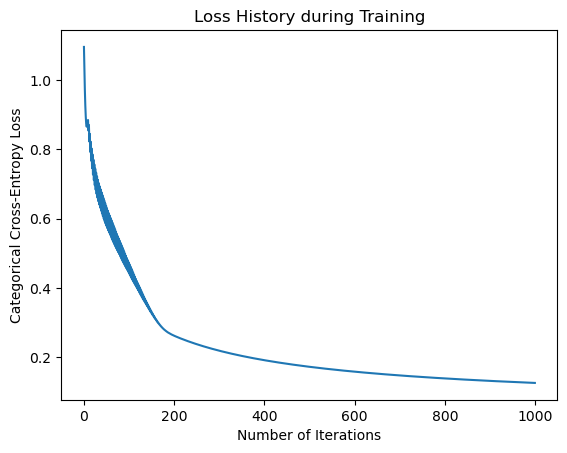

In [23]:
# Visualize the loss history
plt.plot(loss_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("Loss History during Training")
plt.show()

Clean curve witha steep descent at the beginning followed by gradual convergence. This is the expected behavior for full-batch gradient descent.

In [24]:
# Compute predicted classes
y_pred = np.argmax(y_hat, axis=1)
print("Predicted classes:", y_pred)
print("True classes:", y)

Predicted classes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
True classes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [25]:
# Evaluation metrics
accuracy = accuracy_score(y, y_pred)
conf_matrix = confusion_matrix(y, y_pred)
class_report = classification_report(y, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.9866666666666667
Confusion Matrix:
 [[50  0  0]
 [ 0 48  2]
 [ 0  0 50]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.96      0.98        50
           2       0.96      1.00      0.98        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



98.7% accuracy on the training set which is a very good result for a linear model without regularization.

Also, the confusion matrix shows thaat 2 examples from class 1 classified as class 2. This is due to two classes that overlap in the feature space.